# Transfer Learning Short Course — Interactive Demos
Four live simulations, one per lecture. Drag the sliders; the figures update.
Each section first **reproduces the slide figure**, then gives an **interactive** version.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
%matplotlib inline

## L1 — Covariate shift vs. posterior drift
*Left:* covariate shift — the input cloud moves but the labeling rule is shared.
*Middle & right:* posterior drift — the **same** cloud, labeled first by the source rule
then by the target rule. As you drag the angle, the target boundary rotates and the points
**change color** while their positions stay fixed (same $X$, different $P(Y\mid X)$).

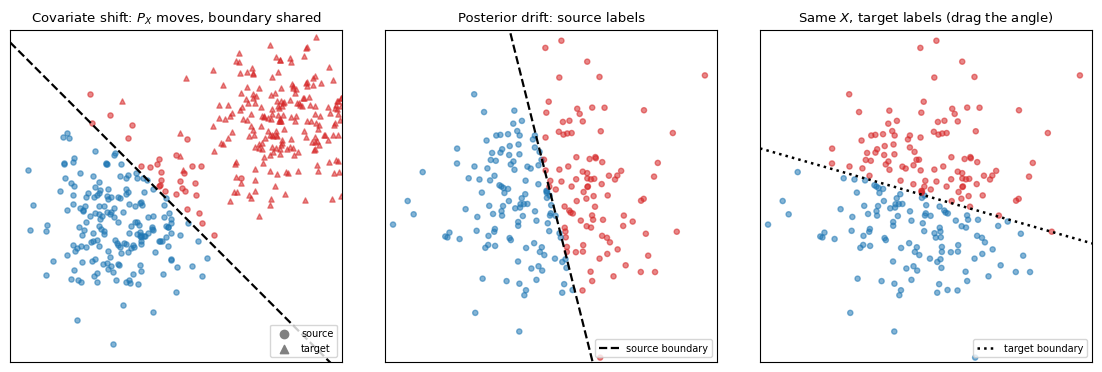

In [2]:
def plot_L1(shift=2.6, angle_deg=60.0):
    rng = np.random.default_rng(0)
    n = 220
    BLUE, RED = "#1f77b4", "#d62728"

    fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(11.4, 3.7))
    xs = np.linspace(-4, 4, 100)

    # ---- Panel 1: covariate shift -- X-cloud moves, decision boundary shared ----
    w = np.array([1.0, 1.0]); b = 0.3
    for center, mk in [((-1.2, -0.6), "o"), ((shift, shift * 0.7), "^")]:
        X = rng.normal(center, 1.0, size=(n, 2))
        lab = (X @ w + b > 0).astype(int)
        axL.scatter(X[lab == 0, 0], X[lab == 0, 1], c=BLUE, marker=mk, s=14, alpha=0.55)
        axL.scatter(X[lab == 1, 0], X[lab == 1, 1], c=RED, marker=mk, s=14, alpha=0.55)
    axL.plot(xs, -(w[0] * xs + b) / w[1], "k--", lw=1.6)
    axL.set_title(r"Covariate shift: $P_X$ moves, boundary shared", fontsize=9.5)
    axL.scatter([], [], c="gray", marker="o", label="source")
    axL.scatter([], [], c="gray", marker="^", label="target")
    axL.legend(fontsize=7, loc="lower right")

    # ---- Panels 2 & 3: posterior drift -- ONE shared cloud, two labelling rules ----
    Xc = rng.normal(0.0, 1.3, size=(n, 2))
    ws = np.array([1.0, 0.25])                 # source labelling direction
    theta = np.deg2rad(angle_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    wt = R @ ws                                # target direction (rotated)
    lab_s = (Xc @ ws > 0).astype(int)          # source labels
    lab_t = (Xc @ wt > 0).astype(int)          # target labels on the SAME points

    axM.scatter(Xc[:, 0], Xc[:, 1], c=np.where(lab_s == 1, RED, BLUE),
                marker="o", s=14, alpha=0.55)
    axM.plot(xs, -(ws[0] * xs) / ws[1], "k--", lw=1.6, label="source boundary")
    axM.set_title(r"Posterior drift: source labels", fontsize=9.5)
    axM.legend(fontsize=7, loc="lower right")

    axR.scatter(Xc[:, 0], Xc[:, 1], c=np.where(lab_t == 1, RED, BLUE),
                marker="o", s=14, alpha=0.55)
    axR.plot(xs, -(wt[0] * xs) / wt[1], "k:", lw=1.8, label="target boundary")
    axR.set_title(r"Same $X$, target labels (drag the angle)", fontsize=9.5)
    axR.legend(fontsize=7, loc="lower right")

    for ax in (axL, axM, axR):
        ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()


plot_L1(shift=2.6, angle_deg=60.0)

In [3]:
interact(plot_L1,
         shift=FloatSlider(min=0.0, max=3.0, step=0.1, value=2.6, description="cov-shift δ"),
         angle_deg=FloatSlider(min=0.0, max=80.0, step=2.0, value=60.0, description="drift angle°"));

interactive(children=(FloatSlider(value=2.6, description='cov-shift δ', max=3.0), FloatSlider(value=60.0, desc…

## L2 — Distribution shift vs. target excess risk
A source-trained classifier deployed on a shifted target: excess risk grows with the
shift, tracking the TV divergence — the divergence-bound story of Lecture 2.

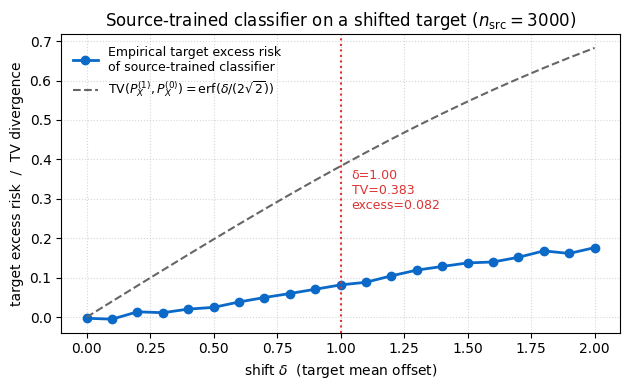

In [4]:
# Train ONE source classifier and precompute the full curve once, so the slider is fast.
_L2_n_source = 3000
_L2_n_target_eval = 8000
L2_deltas = np.linspace(0.0, 2.0, 21)


def _fit_logistic_1d(x, y, n_iter=200, lr=0.5):
    """Plain gradient-descent logistic regression in 1D."""
    a, b = 0.0, 0.0
    for _ in range(n_iter):
        z = a * x + b
        p = 1.0 / (1.0 + np.exp(-z))
        a -= lr * np.mean((p - y) * x)
        b -= lr * np.mean(p - y)
    return a, b


def _bayes_risk_target():
    """Balanced priors -> Bayes 0/1 risk = Phi(-1/2)."""
    return 1.0 - 0.5 * (1.0 + erf(0.5 / sqrt(2.0)))


def _empirical_target_risk(a, b, delta, rng, n=_L2_n_target_eval):
    y = rng.integers(0, 2, size=n)
    x = (delta + y.astype(float)) + rng.standard_normal(n)
    pred = ((a * x + b) > 0).astype(int)
    return float(np.mean(pred != y))


def _l2_precompute():
    rng = np.random.default_rng(0)
    y_src = rng.integers(0, 2, size=_L2_n_source)
    x_src = y_src.astype(float) + rng.standard_normal(_L2_n_source)
    a_hat, b_hat = _fit_logistic_1d(x_src, y_src)
    r_bayes = _bayes_risk_target()
    excess, tv = [], []
    for d in L2_deltas:
        excess.append(_empirical_target_risk(a_hat, b_hat, d, rng) - r_bayes)
        tv.append(erf(d / (2.0 * sqrt(2.0))))   # TV between N(0,1) and N(delta,1)
    return np.array(excess), np.array(tv)


L2_excess, L2_tv = _l2_precompute()


def plot_L2(delta=1.0):
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    ax.plot(L2_deltas, L2_excess, "o-", color="#0b69c7", lw=2,
            label="Empirical target excess risk\nof source-trained classifier")
    ax.plot(L2_deltas, L2_tv, "--", color="#666666", lw=1.5,
            label=r"TV$(P_X^{(1)},P_X^{(0)}) = \mathrm{erf}(\delta/(2\sqrt{2}))$")
    j = int(np.argmin(np.abs(L2_deltas - delta)))
    tv_here = erf(delta / (2.0 * sqrt(2.0)))
    ax.axvline(delta, color="#d33", ls=":", lw=1.5)
    ax.annotate(f"δ={delta:.2f}\nTV={tv_here:.3f}\nexcess={L2_excess[j]:.3f}",
                xy=(delta, L2_tv[j]), xytext=(8, -2), textcoords="offset points",
                fontsize=9, color="#d33", va="top")
    ax.set_xlabel(r"shift $\delta$  (target mean offset)")
    ax.set_ylabel("target excess risk  /  TV divergence")
    ax.set_title(r"Source-trained classifier on a shifted target ($n_{\mathrm{src}}=3000$)")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


plot_L2(1.0)

In [5]:
interact(plot_L2, delta=FloatSlider(min=0.0, max=2.0, step=0.1, value=1.0, description="shift δ"));

interactive(children=(FloatSlider(value=1.0, description='shift δ', max=2.0), Output()), _dom_classes=('widget…

## L3 — Importance weighting under covariate shift
Source and target differ in $X$; a mis-specified linear fit on source is biased.
IW-ERM with **true** weights recovers the oracle as the source grows. With **estimated**
weights, a *fixed* unlabeled-target pool ($n_\mathrm{tgt}=400$) plateaus **above** the oracle
(the weights are only as good as that target sample); letting the target grow with $n_1$ — or
raising the clip — closes the gap. Drag the sliders to see both effects.

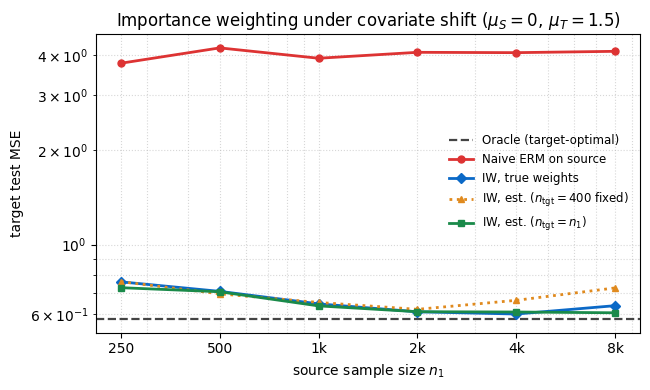

In [6]:
def plot_L3(mu_t=1.5, clip=50.0, n_reps=10):
    from matplotlib.ticker import NullFormatter
    rng = np.random.default_rng(0)
    MU_S = 0.0
    SIGMA_X = 1.0
    NOISE = 0.3
    N_TGT_FIXED = 400          # the realistic case: a fixed unlabeled-target pool
    N_TEST = 15000
    n_srcs = [250, 500, 1000, 2000, 4000, 8000]

    def true_function(x):
        return 0.5 * x ** 2

    def features(x):
        return np.column_stack([np.ones_like(x), x])  # linear (mis-specified)

    def true_density_ratio(x):
        return np.exp(-0.5 * ((x - mu_t) ** 2 - (x - MU_S) ** 2) / SIGMA_X ** 2)

    def fit_logistic(X, z, n_iter=500, lr=0.2, l2=1e-3):
        w = np.zeros(X.shape[1])
        for _ in range(n_iter):
            prob = 1.0 / (1.0 + np.exp(-(X @ w)))
            w -= lr * (X.T @ (prob - z) / len(z) + l2 * w)
        return w

    def weighted_ls(Phi, y, w):
        W = w.reshape(-1, 1)
        A = Phi.T @ (W * Phi)
        b = Phi.T @ (W * y.reshape(-1, 1))
        return np.linalg.solve(A + 1e-8 * np.eye(A.shape[0]), b).ravel()

    def target_test_mse(beta):
        x = mu_t + SIGMA_X * rng.standard_normal(N_TEST)
        y = true_function(x) + NOISE * rng.standard_normal(N_TEST)
        return float(np.mean((y - features(x) @ beta) ** 2))

    def est_ratio(x_src, x_tgt):
        Xs, Xt = features(x_src), features(x_tgt)
        X = np.vstack([Xs, Xt])
        z = np.concatenate([np.zeros(len(Xs)), np.ones(len(Xt))])
        w = fit_logistic(X, z)
        p1 = 1.0 / (1.0 + np.exp(-(features(x_src) @ w)))
        r = (p1 / (1.0 - p1 + 1e-9)) * (len(Xs) / len(Xt))
        r /= r.mean()
        return np.clip(r, 0.0, clip)

    # oracle = population target-optimal linear fit (a flat floor)
    xo = mu_t + SIGMA_X * rng.standard_normal(200000)
    yo = true_function(xo) + NOISE * rng.standard_normal(200000)
    floor = target_test_mse(weighted_ls(features(xo), yo, np.ones(len(xo))))

    labs = ["naive", "iw_true", "iw_fixed", "iw_grow"]
    res = {k: np.zeros((len(n_srcs), n_reps)) for k in labs}
    for i, ns in enumerate(n_srcs):
        for r in range(n_reps):
            xs_ = MU_S + SIGMA_X * rng.standard_normal(ns)
            ys_ = true_function(xs_) + NOISE * rng.standard_normal(ns)
            Phi = features(xs_)
            res["naive"][i, r] = target_test_mse(weighted_ls(Phi, ys_, np.ones(ns)))
            wt = true_density_ratio(xs_); wt /= wt.mean()
            res["iw_true"][i, r] = target_test_mse(weighted_ls(Phi, ys_, wt))
            xf = mu_t + SIGMA_X * rng.standard_normal(N_TGT_FIXED)
            res["iw_fixed"][i, r] = target_test_mse(weighted_ls(Phi, ys_, est_ratio(xs_, xf)))
            xg = mu_t + SIGMA_X * rng.standard_normal(ns)
            res["iw_grow"][i, r] = target_test_mse(weighted_ls(Phi, ys_, est_ratio(xs_, xg)))
    means = {k: res[k].mean(axis=1) for k in labs}

    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    ax.axhline(floor, color="#444", ls="--", lw=1.6, label="Oracle (target-optimal)")
    sty = {
        "naive":   ("o-",  "#d33",     "Naive ERM on source"),
        "iw_true": ("D-",  "#0b69c7",  "IW, true weights"),
        "iw_fixed":("^:",  "#e08a1e",  r"IW, est. ($n_{\mathrm{tgt}}{=}400$ fixed)"),
        "iw_grow": ("s-",  "#1a8a4a",  r"IW, est. ($n_{\mathrm{tgt}}{=}n_1$)"),
    }
    for k in labs:
        st, c, l = sty[k]
        ax.plot(n_srcs, means[k], st, color=c, lw=2, ms=5, label=l)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(n_srcs); ax.set_xticklabels(["250", "500", "1k", "2k", "4k", "8k"])
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="x", which="minor", length=0)
    ax.set_xlabel(r"source sample size $n_1$")
    ax.set_ylabel("target test MSE")
    ax.set_title(r"Importance weighting under covariate shift ($\mu_S{=}0,\,\mu_T{=}%.1f$)" % mu_t)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(loc="center right", frameon=False, fontsize=8.5)
    fig.tight_layout()
    plt.show()


plot_L3(1.5, 50.0, 10)

In [7]:
interact(plot_L3,
         mu_t=FloatSlider(min=0.5, max=2.5, step=0.1, value=1.5, description="target μ"),
         clip=FloatSlider(min=2.0, max=50.0, step=2.0, value=50.0, description="weight clip W"),
         n_reps=IntSlider(min=6, max=24, step=2, value=10, description="reps"));

interactive(children=(FloatSlider(value=1.5, description='target μ', max=2.5, min=0.5), FloatSlider(value=50.0…

## L4 — Biased ridge: "safe transfer" under posterior drift
Biased ridge picks its penalty λ by cross-validation ("anchor + leash"): it tracks the
better of pure-transfer and target-only. With target-only OLS (n₀ > p) the target-only
curve is flat, so pure transfer (σ² + ‖δ‖²) crosses it at the target-only variance — the
"safe-transfer crossover" (dotted line). Drag n₀ to move the crossover.

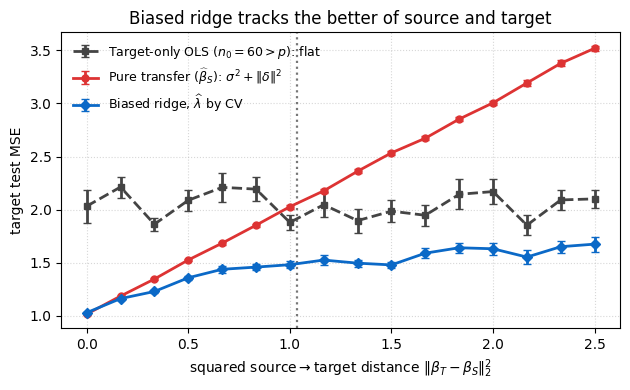

In [8]:
def plot_L4(n_0=60, n_reps=12):
    rng = np.random.default_rng(0)
    p = 30
    n_S = 2000        # large source sample
    sigma = 1.0       # noise
    n_test = 8000
    n_0 = max(int(n_0), p + 5)                       # keep target-only OLS well-defined
    deltasq_grid = np.linspace(0.0, 2.5, 16)         # x-axis = ||delta||^2
    lam_grid = np.concatenate([[0.0], np.geomspace(0.1, 1000.0, 12)])

    def make_data(beta, n):
        X = rng.standard_normal((n, p))
        y = X @ beta + sigma * rng.standard_normal(n)
        return X, y

    def ols(X, y):
        return np.linalg.lstsq(X, y, rcond=None)[0]

    def biased_ridge(X, y, lam, anchor):
        A = X.T @ X + lam * np.eye(X.shape[1])
        return np.linalg.solve(A, X.T @ y + lam * anchor)

    def cv_biased_ridge(X, y, anchor, k=5):
        folds = np.array_split(rng.permutation(len(y)), k)
        best_lam, best_err = lam_grid[0], np.inf
        for lam in lam_grid:
            err = 0.0
            for j in range(k):
                te = folds[j]
                tr = np.concatenate([folds[m] for m in range(k) if m != j])
                b = biased_ridge(X[tr], y[tr], lam, anchor)
                err += np.sum((y[te] - X[te] @ b) ** 2)
            if err < best_err:
                best_err, best_lam = err, lam
        return biased_ridge(X, y, best_lam, anchor)

    def test_mse(beta_hat, beta_true):
        Xte = rng.standard_normal((n_test, p))
        yte = Xte @ beta_true + sigma * rng.standard_normal(n_test)
        return float(np.mean((yte - Xte @ beta_hat) ** 2))

    labels = ["target_only", "pure_transfer", "biased_ridge"]
    mse = {k: np.zeros((len(deltasq_grid), n_reps)) for k in labels}
    for r in range(n_reps):
        beta_S = rng.standard_normal(p)
        direction = rng.standard_normal(p); direction /= np.linalg.norm(direction)
        XS, yS = make_data(beta_S, n_S)
        beta_S_hat = ols(XS, yS)
        for i, dsq in enumerate(deltasq_grid):
            beta_T = beta_S + np.sqrt(dsq) * direction
            XT, yT = make_data(beta_T, n_0)
            mse["target_only"][i, r] = test_mse(ols(XT, yT), beta_T)
            mse["pure_transfer"][i, r] = test_mse(beta_S_hat, beta_T)
            mse["biased_ridge"][i, r] = test_mse(cv_biased_ridge(XT, yT, beta_S_hat), beta_T)

    means = {k: mse[k].mean(axis=1) for k in labels}
    ses = {k: mse[k].std(axis=1) / np.sqrt(n_reps) for k in labels}
    threshold = p / (n_0 - p - 1)                    # crossover = target-only variance

    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    styles = {
        "target_only":   ("s--", "#444",    r"Target-only OLS ($n_0{=}%d>p$): flat" % n_0),
        "pure_transfer": ("o-",  "#d33",     r"Pure transfer ($\widehat\beta_S$): $\sigma^2+\|\delta\|^2$"),
        "biased_ridge":  ("D-",  "#0b69c7",  r"Biased ridge, $\widehat\lambda$ by CV"),
    }
    for k in labels:
        style, color, lab = styles[k]
        ax.errorbar(deltasq_grid, means[k], yerr=ses[k], fmt=style, color=color, lw=2,
                    ms=5, capsize=3, label=lab)
    ax.axvline(threshold, color="#777", ls=":", lw=1.6)
    ax.set_xlabel(r"squared source$\to$target distance $\|\beta_T-\beta_S\|_2^2$")
    ax.set_ylabel("target test MSE")
    ax.set_title("Biased ridge tracks the better of source and target")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


plot_L4(60, 12)

In [9]:
interact(plot_L4,
         n_0=IntSlider(min=40, max=150, step=10, value=60, description="target n₀"),
         n_reps=IntSlider(min=8, max=40, step=4, value=12, description="reps"));

interactive(children=(IntSlider(value=60, description='target n₀', max=150, min=40, step=10), IntSlider(value=…